# Feature Engineering 2

本 Notebook 承接 `04_feature_engineering.ipynb`，记录 Feature Engineering Round 2 从**修正筛选标尺**到**收敛实验树**的完整过程：以 FE10 为固定 Reference，用 NULL / Negative-Control 校准 feature-addition noise，再用 6 个完整 5-Fold 实验验证 numerical、categorical interaction 与历史 Audit 分支，最后通过 R_GROUP LOO 归因真正有贡献的 residual 成员。

---

## Table of Contents

1. [实验背景与正式 Reference](#r2-num-setup)
   - 1.1 [Round 1 在哪里结束](#r2-num-contract)
   - 1.2 [导入依赖与定位项目路径](#r2-num-imports)
2. [重新设计筛选策略](#r2-strategy)
3. [FE20–FE46 候选目录与实现假设](#r2-num-catalog)
   - 3.1 [FE20–FE29：Numerical](#r2-num-catalog)
   - 3.2 [FE30–FE46：Categorical interactions](#r2-cat-catalog)
   - 3.3 [交互实现与实际模型设置](#r2-cat-implementation)
4. [受控实验协议、运行顺序与决策线](#r2-num-run)
5. [NULL / Negative-Control 完整结果](#r2-null-results)
6. [第一阶段 6 个实验的完整 5-Fold 证据](#r2-num-results)
   - 6.1 [Numerical 分支](#r2-num-analysis)
   - 6.2 [Categorical interaction 分支](#r2-cat-results)
   - 6.3 [整体决策与解释边界](#r2-num-decisions)
7. [R_GROUP LOO：第二阶段归因](#r2-loo)
8. [Feature Engineering 结论与后续边界](#r2-num-next)
---

<a id="r2-num-setup" name="r2-num-setup"></a>

## 1. 实验背景与正式 Reference

<a id="r2-num-contract" name="r2-num-contract"></a>

### 1.1 Round 1 在哪里结束

`04_feature_engineering.ipynb` 已经完成从 19 组候选到 FE10 的第一轮收敛。FE10 把总屏幕时间中没有被社交、游戏、工作/学习三个字段解释的部分单独交给模型：

```python
unknown_activity_time = (
    daily_screen_time_hours
    - social_media_hours
    - gaming_hours
    - work_study_hours
)
```

它是当前最简单、最稳定的 Feature Reference：

| 项目 | 结果 |
|---|---:|
| Reference | **FE10 — `unknown_activity_time`** |
| 5-Fold CV AUC | **`0.964629 ± 0.000523`** |
| Mean Δ vs BASE | **`+0.000621`** |
| 正向 Fold | **5/5** |
| Public LB | **`0.96606`** |

Round 2 不再问“candidate 是否优于原始 BASE”，而是统一回答：

```text
delta_vs_reference
= AUC(FE10 + candidate / feature group) - AUC(FE10)
```

比较必须发生在同一个 Fold 下。这样可以抵消不同 Fold 本身难度的差异，把注意力集中到“多加这些特征后，模型究竟移动了多少”。

Round 2 的目标不是继续堆很多变换，而是回答两个更窄的问题：FE10 之外是否仍有稳定的时间预算增量，以及显式 categorical interaction 是否能补充 CatBoost 已有的非线性建模能力。

<a id="r2-num-imports" name="r2-num-imports"></a>

### 1.2 导入依赖与定位项目路径

In [2]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.round2_features import ROUND2_FEATURE_SETS

NULL_RESULTS_DIR = PROJECT_ROOT / "results" / "noise_calibration"
ROUND2_RESULTS_DIR = PROJECT_ROOT / "results" / "round2" / "first_stage"
ROUND2_LOO_DIR = PROJECT_ROOT / "results" / "round2" / "r_group_loo"
NULL_SUMMARY_PATH = NULL_RESULTS_DIR / "summary.csv"
ROUND2_SUMMARY_PATH = ROUND2_RESULTS_DIR / "summary.csv"

<a id="r2-strategy" name="r2-strategy"></a>

## 2. 重新设计筛选策略

Round 1 曾用 `CV_STD = 0.000473` 衡量候选增量，但它来自 BASE 五个 Fold 的**绝对 AUC 标准差**。Round 2 比较的是相同 Fold 下 `candidate - FE10` 的配对差值，两者不是同一类波动。已有实验中，FE09、FE10、FE19 的 paired-delta Std 只有约 `0.000042–0.000092`，继续用 `0.000473` 会把一些边缘信号机械压成 Reject。

另一个问题是 multiple comparisons：如果几十个候选都只跑 Fold 1，再从中选择最好看的结果，即使真实效应全为零，也容易挑中一个偶然的正数，形成 winner's curse。因此 Round 2 不再使用“27 candidates × Fold 1 排名”，而是先验证较少的机制分支。

| 名称 | 在实验树中的含义 | 是否直接进入第一阶段 |
|---|---|---|
| NULL / Negative-Control | 测量多加无信息列时模型自身会漂多少 | 是，但不属于 FE 候选 |
| Active | 当前先验最高、直接进入完整 5-Fold 的成员 | 是 |
| Conditional Reserve | 只有同方向 Active family 成立后才可能唤醒 | 否 |
| Audit | 因旧标尺可能误判而获得一次公平复审的历史候选 | 是 |
| Drop | 本轮不测试，也不占新的 FE ID | 否 |

Coverage、single-feature AUC、correlation 与 hard constraint 仍可用来形成先验，但它们只是 cheap diagnostics。FE27 的 coverage 与单变量 AUC 很强，最后却在正式 5-Fold 中 0/5 为正；这说明“单列本身会排序”不等于“加入 FE10 后仍有增量”。

<a id="r2-num-catalog" name="r2-num-catalog"></a>

## 3. FE20–FE46 候选目录与实现假设

### 3.1 FE20–FE29：Numerical

为方便阅读，使用以下缩写：

```text
D  = daily_screen_time_hours
S  = social_media_hours
G  = gaming_hours
W  = work_study_hours
WK = weekend_screen_time
U  = FE10 = D - S - G - W
```

本轮不再把所有候选逐个做 Fold 1 排名。Active / Audit 先按机制组成完整 5-Fold 实验；Conditional Reserve 只有在同方向实验成立后才考虑。

| 思路 | 候选 | 第一阶段实验 | 想回答的问题 |
|---|---|---|---|
| Residual / partial residual | FE20–FE25 | `R_GROUP` = FE20 + FE22 + FE25 | FE10 之外是否仍有更容易被树利用的时间预算方向？ |
| Linear balance | FE26 | FE26 单独 | leisure 与 work/study 的差是否提供独立行为轴？ |
| Screen aggregation | FE27 | FE27 单独 | 日常与周末屏幕时间的均值是否比原始两列更稳定？ |
| Ratio Audit | FE28–FE29 | `O_GROUP` | 旧 FE07 / FE16 的单折弱正信号是否能在完整五折复现？ |

In [2]:
NUMERICAL_FEATURE_INFO = {
    "FE20": ("D - S", "Active", "R_GROUP", "去除社交后的 screen residual 可能补充 FE10。"),
    "FE21": ("D - G", "Conditional Reserve", "R_GROUP 成功后考虑", "检验去除 gaming 后的 residual。"),
    "FE22": ("D - W", "Active", "R_GROUP", "去除工作学习后的 screen residual 可能保留娱乐与未知活动。"),
    "FE23": ("D - S - G", "Conditional Reserve", "R_GROUP 成功后考虑", "近似 W + U，检验 work 与未知活动的联合方向。"),
    "FE24": ("D - S - W", "Conditional Reserve", "R_GROUP 成功后考虑", "近似 G + U，检验 gaming 与未知活动的联合方向。"),
    "FE25": ("D - G - W", "Active", "R_GROUP", "近似 S + U，检验 social 与未知活动的联合方向。"),
    "FE26": ("S + G - W", "Active", "单独 5-Fold", "leisure 与 work/study 的斜向差可能刻画用途失衡。"),
    "FE27": ("mean(D, WK)", "Active", "单独 5-Fold", "两个屏幕时间测量的均值可能降低单列噪声。"),
    "FE28": ("W / D", "Audit", "O_GROUP", "公平复审旧 FE07 的弱正向 Fold 1 信号。"),
    "FE29": ("(S + G) / D", "Audit", "O_GROUP", "公平复审旧 FE16 的弱正向 Fold 1 信号。"),
}

catalog_rows = []
for feature_id, (definition, status, experiment, hypothesis) in NUMERICAL_FEATURE_INFO.items():
    catalog_rows.append({
        "特征": feature_id,
        "定义": definition,
        "状态": status,
        "第一阶段用途": experiment,
        "建模假设": hypothesis,
    })

numerical_catalog = pd.DataFrame(catalog_rows)
display(numerical_catalog)

,特征,定义,状态,第一阶段用途,建模假设
0,FE20,D - S,Active,R_GROUP,去除社交后的 screen residual 可能补充 FE10。
1,FE21,D - G,Conditional Reserve,R_GROUP 成功后考虑,检验去除 gaming 后的 residual。
2,FE22,D - W,Active,R_GROUP,去除工作学习后的 screen residual 可能保留娱乐与未知活动。
3,FE23,D - S - G,Conditional Reserve,R_GROUP 成功后考虑,近似 W + U，检验 work 与未知活动的联合方向。
4,FE24,D - S - W,Conditional Reserve,R_GROUP 成功后考虑,近似 G + U，检验 gaming 与未知活动的联合方向。
5,FE25,D - G - W,Active,R_GROUP,近似 S + U，检验 social 与未知活动的联合方向。
6,FE26,S + G - W,Active,单独 5-Fold,leisure 与 work/study 的斜向差可能刻画用途失衡。
7,FE27,"mean(D, WK)",Active,单独 5-Fold,两个屏幕时间测量的均值可能降低单列噪声。
8,FE28,W / D,Audit,O_GROUP,公平复审旧 FE07 的弱正向 Fold 1 信号。
9,FE29,(S + G) / D,Audit,O_GROUP,公平复审旧 FE16 的弱正向 Fold 1 信号。


<a id="r2-cat-catalog" name="r2-cat-catalog"></a>

### 3.2 FE30–FE46：Categorical interactions

更新版计划删除了 `impact × sleep`，因此 Round 2 的 canonical numbering 到 FE46 结束。第一阶段只运行每条机制支线中最有代表性的 Active；其余成员保留为 Conditional Reserve。

| ID | 定义 | 状态 | 第一阶段用途 |
|---|---|---|---|
| FE30 | gender × gaming | Active | CAT_NUM_GROUP |
| FE31 | gender × social | Active | CAT_NUM_GROUP |
| FE32 | gender × screen | Conditional Reserve+ | Gender 方向成立后优先 |
| FE33 | gender × FE10 | Conditional Reserve | Gender 方向成立后考虑 |
| FE34 | stress × sleep | Active | CAT_NUM_GROUP |
| FE35 | stress × screen | Conditional Reserve+ | Stress 方向成立后优先 |
| FE36 | stress × FE10 | Conditional Reserve | Stress 方向成立后考虑 |
| FE37 | stress × work | Conditional Reserve（低优先） | Stress 方向明显成立后 |
| FE38 | stress × social | Conditional Reserve+ | Stress 方向成立后优先 |
| FE39 | impact × work | Active | CAT_NUM_GROUP |
| FE40 | impact × screen | Active | CAT_NUM_GROUP |
| FE41 | impact × FE10 | Conditional Reserve | Impact 方向成立后考虑 |
| FE42 | impact × social | Conditional Reserve+ | Impact 方向成立后优先 |
| FE43 | gender × stress | Active | CAT2_GROUP |
| FE44 | gender × impact | Active | CAT2_GROUP |
| FE45 | stress × impact | Active | CAT2_GROUP，先验最高的二阶组合 |
| FE46 | gender × stress × impact | Conditional Reserve | CAT2_GROUP 成立后才唤醒 |

第一阶段的 categorical 问题被压缩成两个 group：`CAT_NUM_GROUP = FE30 + FE31 + FE34 + FE39 + FE40` 检查人工 gated numerical interaction 这一方向；`CAT2_GROUP = FE43 + FE44 + FE45` 检查显式二阶 categorical combination。

<a id="r2-cat-implementation" name="r2-cat-implementation"></a>

### 3.3 交互实现与实际模型设置

Categorical × numerical 不使用没有真实顺序含义的 `category_code × numerical`。以 FE30 为例，`gender × gaming` 被展开为 `gaming_by_gender__Female`、`__Male`、`__Other`、`__Missing`：类别匹配时保留原 numerical value，不匹配时为 NaN；原始 category、原始 numerical 与 numerical missing flag 同时保留。这样既不伪造类别顺序，也能区分类别不匹配和 numerical 自身缺失。

Categorical × categorical 使用显式字符串组合，例如 `Female__High`，并把新列明确加入 CatBoost `cat_features`。

计划稿曾按 effective `max_ctr_complexity = 1` 设计独立 MCC01，但实际第一阶段 `protocol.json` 记录的是 **`max_ctr_complexity = 4`**。因此本 Notebook 以真实运行协议为准：CAT2 结果衡量的是“在当前 CatBoost 已能构造较高阶 CTR 组合时，额外提供显式字符串组合是否还有增量”，而不是在一个只允许一阶 CTR 的模型上测试交互。

<a id="r2-num-run" name="r2-num-run"></a>

## 4. 受控实验协议、运行顺序与决策线

所有正式实验固定使用同一套 Fold 和显式模型参数，只改变 FE10 之外新增的特征。现场 `protocol.json` 记录的核心设置如下：

| 项目 | 固定值 |
|---|---|
| Reference | 同 Fold 的 FE10 JSON |
| CV | `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` |
| CatBoost | 10,000 iterations、learning rate 0.05、depth 6、AUC |
| Early stopping | 200 rounds |
| random seed / thread count | 42 / 10 |
| Round 2 protocol / config | `catboost_fe10_round2_first_stage_v1` / `07f0d4012220` |
| 核心指标 | 同 Fold `delta_vs_reference` |

### 从校准到归因

```text
Stage 0  参数、categorical dtype 与实际模型设置检查
   ↓
Stage 1  NULL-A 5-Fold + 两个 NULL-B seed × 5-Fold = 15 fits
   ↓
Stage 2  FE27 → R_GROUP → FE26 → CAT_NUM_GROUP → CAT2_GROUP → O_GROUP
         6 个实验 × 5-Fold = 30 fits
   ↓
Stage 3  只有通过的 group 进入 LOO；Reserve 不自动运行
   ↓
Stage 4  组装最小候选集合，再用 random_state=2024 做 5-Fold 稳健性复核
```

第一阶段加上 NULL 共 45 fits。完整五折直接验证机制方向，避免从大量单 Fold 结果中挑选最幸运的候选。

### 看结果前固定的启发式决策线

三个 NULL 的 population Std 分别约为 `0.0000703`、`0.0000875`、`0.0000599`。这里不把 15 个 delta 忽略组别后直接混在一起，而是先保留每个 control 的 Fold 内波动，再用均方根合并：

```text
σ_null = √mean(σ_A², σ_B1001², σ_B1002²) ≈ 0.0000734
5-Fold mean noise ≈ σ_null / √5
decision line = 2 × σ_null / √5 ≈ +0.0000657
```

第一阶段的继续研究条件为：

1. `mean_delta ≥ +0.0000657`；
2. 至少 `4/5` Fold 为正。

第一条检查平均效应是否明显高于实测 noise scale，第二条检查方向是否跨 Fold 一致。这只是工程 decision rule，不是 p-value 或正式 95% 显著性检验：五个训练集高度重叠，Fold delta 不独立，NULL 数量有限，而且两个 permutation control 存在负偏。

### Group screening 不等于 individual verdict

Group positive 说明该 family 值得拆 LOO；group near zero 或 negative 只说明“这些成员一起加入”的方案没有通过，不能数学上证明组内每个成员都无效，因为 CatBoost 中的特征会竞争 split、彼此冗余并改变树结构。失败 group 的 Reserve 不自动解锁，但高先验成员可以保留一个可选的 individual rescue / sanity check；是否补测必须在看结果后另行登记，不能悄悄改写原门槛。

复现实验时从项目根目录使用以下入口；这些命令会训练模型并写入或覆盖逐折 JSON：

```bash
python -m src.noise_calibration
python -m src.round2_experiment FE27 R_GROUP FE26 CAT_NUM_GROUP CAT2_GROUP O_GROUP
python -m src.summarize_round2

python -m src.round2_experiment R_MINUS_FE20 R_MINUS_FE22 R_MINUS_FE25
python -m src.summarize_round2 --results-dir results/round2/r_group_loo
```

<a id="r2-null-results" name="r2-null-results"></a>

## 5. NULL / Negative-Control 完整结果

NULL 不是候选特征，也不会进入最终 feature set。NULL-A 新增与 `daily_screen_time_hours` 严格单调等价的 `2 × D - 3`，用来测量冗余列造成的 split competition；NULL-B 用 seed 1001、1002 分别打乱同一列，在保留数值分布、尺度、dtype 与缺失比例的同时破坏 row-level 信息。三组实验各跑完整 5-Fold，共 15 fits。

下表从逐折 JSON 重新计算 sample standard deviation（`ddof=1`），便于和 Round 2 表格一致；用于启发式门槛的 `σ_null` 则沿用 NULL 保存汇总中的 population Std（`ddof=0`）。两种口径必须明确标注，它们只改变 Std 的展示与校准计算，不改变任何 AUC 或 paired delta。

In [3]:
if not NULL_SUMMARY_PATH.exists():
    raise FileNotFoundError("未找到 NULL summary.csv。")

null_saved_summary = pd.read_csv(NULL_SUMMARY_PATH)
null_records = [
    json.loads(path.read_text(encoding="utf-8"))
    for path in sorted(NULL_RESULTS_DIR.glob("null_*_fold*.json"))
]
null_folds = pd.DataFrame(null_records)

if len(null_folds) != 15:
    raise ValueError(f"NULL 结果应为 15 条，当前为 {len(null_folds)} 条。")

null_analysis = (
    null_folds.groupby("experiment_id")
    .agg(
        mean_auc=("auc", "mean"),
        mean_delta=("delta_vs_reference", "mean"),
        positive_folds=("delta_vs_reference", lambda values: int((values > 0).sum())),
        delta_std=("delta_vs_reference", "std"),
        mean_abs_delta=("delta_vs_reference", lambda values: values.abs().mean()),
        max_abs_delta=("delta_vs_reference", lambda values: values.abs().max()),
        mean_best_iteration=("best_iteration", "mean"),
    )
    .reset_index()
    .merge(null_saved_summary[["experiment_id", "mean_elapsed"]], on="experiment_id", how="left")
)

null_view = null_analysis.rename(columns={
    "experiment_id": "实验",
    "mean_auc": "平均 AUC",
    "mean_delta": "平均 Δ",
    "positive_folds": "正向 Fold",
    "delta_std": "Δ Std (ddof=1)",
    "mean_abs_delta": "Mean |Δ|",
    "max_abs_delta": "Max |Δ|",
    "mean_best_iteration": "平均最佳轮数",
    "mean_elapsed": "平均耗时",
})

display(null_view)

,实验,平均 AUC,平均 Δ,正向 Fold,Δ Std (ddof=1),Mean |Δ|,Max |Δ|,平均最佳轮数,平均耗时
0,NULL_A_AFFINE,0.964644,0.000016,3,0.000079,0.000051,0.000148,7864.2,10m 54s
1,NULL_B_PERM_1001,0.964531,-0.000098,1,0.000098,0.000121,0.000176,7799.6,10m 54s
2,NULL_B_PERM_1002,0.964507,-0.000122,0,0.000067,0.000122,0.000182,7698.0,10m 36s


experiment_id,NULL_A_AFFINE,NULL_B_PERM_1001,NULL_B_PERM_1002
fold,,,
1,0.000015,-0.000173,-0.000111
2,0.000148,0.000058,-0.000017
3,-0.000044,-0.000176,-0.000179
4,0.000004,-0.000131,-0.000182
5,-0.000044,-0.000067,-0.000120


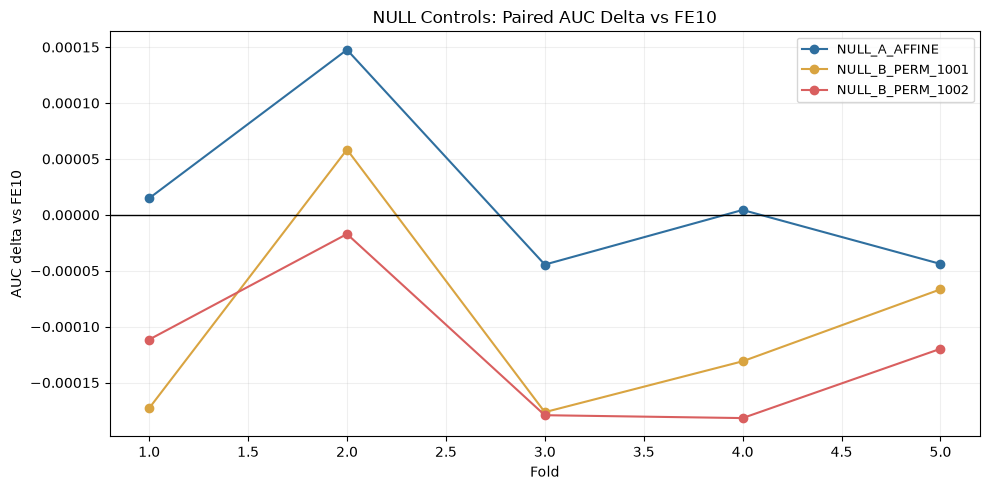

In [4]:
null_pivot = null_folds.pivot(
    index="fold",
    columns="experiment_id",
    values="delta_vs_reference",
)
display(null_pivot)

ax = null_pivot.plot(
    marker="o",
    figsize=(10, 5),
    color={
        "NULL_A_AFFINE": "#2f6f9f",
        "NULL_B_PERM_1001": "#d9a441",
        "NULL_B_PERM_1002": "#d95f5f",
    },
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("NULL Controls: Paired AUC Delta vs FE10")
ax.set_xlabel("Fold")
ax.set_ylabel("AUC delta vs FE10")
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

<a id="r2-num-results" name="r2-num-results"></a>

## 6. 第一阶段 6 个实验的完整 5-Fold 证据

六个第一阶段实验已经形成 `6 × 5 = 30` 条同折配对结果。本节先保留 numerical 的逐折表和图，再把原计划中属于 06 的 categorical interaction 结果合并进来；从此所有 Round 2 FE 证据都在同一个 Notebook 中收口。

<a id="r2-num-analysis" name="r2-num-analysis"></a>

### 6.1 Numerical 分支

In [5]:
NUMERICAL_EXPERIMENTS = ["FE27", "R_GROUP", "FE26", "O_GROUP"]

if not ROUND2_SUMMARY_PATH.exists():
    raise FileNotFoundError("未找到 Round 2 summary.csv。")

round2_summary = pd.read_csv(ROUND2_SUMMARY_PATH)
numerical_summary = (
    round2_summary.loc[round2_summary["experiment_id"].isin(NUMERICAL_EXPERIMENTS)]
    .sort_values("mean_delta", ascending=False)
    .copy()
)

numerical_view = numerical_summary[[
    "experiment_id",
    "feature_ids",
    "mean_auc",
    "mean_delta",
    "positive_folds",
    "delta_std",
    "mean_abs_delta",
    "max_abs_delta",
    "mean_best_iteration",
]].rename(columns={
    "experiment_id": "实验",
    "feature_ids": "特征",
    "mean_auc": "平均 AUC",
    "mean_delta": "平均 Δ",
    "positive_folds": "正向 Fold",
    "delta_std": "Δ Std",
    "mean_abs_delta": "Mean |Δ|",
    "max_abs_delta": "Max |Δ|",
    "mean_best_iteration": "平均最佳轮数",
})
display(numerical_view)

,实验,特征,平均 AUC,平均 Δ,正向 Fold,Δ Std,Mean |Δ|,Max |Δ|,平均最佳轮数
0,R_GROUP,FE20 + FE22 + FE25,0.964707,0.000079,5,0.000062,0.000079,0.000167,7601.8
1,O_GROUP,FE28 + FE29,0.964677,0.000048,4,0.000073,0.000064,0.000161,7619.6
2,FE26,FE26,0.964633,0.000004,2,0.000071,0.000047,0.000128,7733.0
4,FE27,FE27,0.964545,-0.000084,0,0.000046,0.000084,0.000126,8268.4


experiment_id,FE26,FE27,O_GROUP,R_GROUP
fold,,,,
1,0.000002,-0.000081,0.000034,0.000167
2,0.000128,-0.000009,0.000161,0.000100
3,-0.000027,-0.000114,-0.000040,0.000038
4,-0.000043,-0.000089,0.000028,0.000005
5,-0.000039,-0.000126,0.000057,0.000085


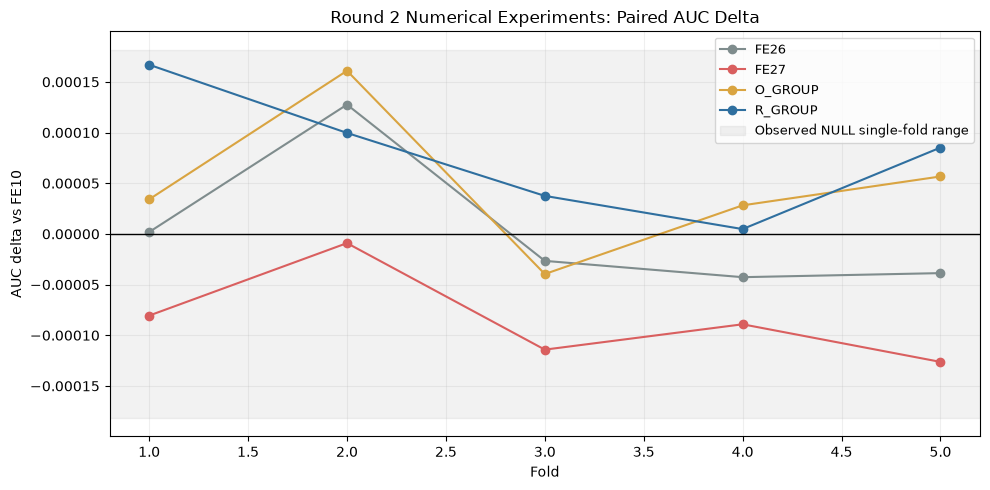

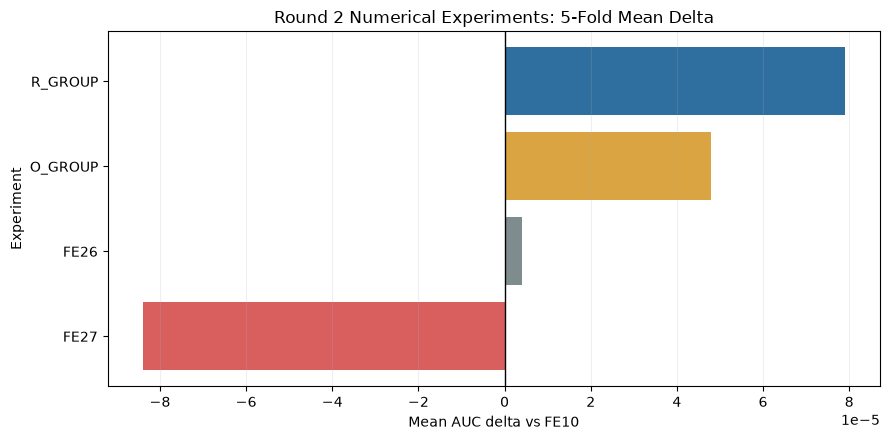

In [6]:
round2_records = []
for path in sorted(ROUND2_RESULTS_DIR.glob("*_fold*.json")):
    result = json.loads(path.read_text(encoding="utf-8"))
    if result.get("experiment_id") in NUMERICAL_EXPERIMENTS:
        round2_records.append(result)

numerical_folds = pd.DataFrame(round2_records)
if len(numerical_folds) != 20:
    raise ValueError(f"Numerical 第一阶段结果应为 20 条，当前为 {len(numerical_folds)} 条。")

numerical_pivot = numerical_folds.pivot(
    index="fold",
    columns="experiment_id",
    values="delta_vs_reference",
)
display(numerical_pivot)

NULL_MAX_ABS_DELTA = null_folds["delta_vs_reference"].abs().max()

ax = numerical_pivot.plot(
    marker="o",
    figsize=(10, 5),
    color={
        "R_GROUP": "#2f6f9f",
        "O_GROUP": "#d9a441",
        "FE26": "#7f8c8d",
        "FE27": "#d95f5f",
    },
)
ax.axhspan(
    -NULL_MAX_ABS_DELTA,
    NULL_MAX_ABS_DELTA,
    color="gray",
    alpha=0.10,
    label="Observed NULL single-fold range",
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Round 2 Numerical Experiments: Paired AUC Delta")
ax.set_xlabel("Fold")
ax.set_ylabel("AUC delta vs FE10")
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

mean_delta_plot = numerical_summary.sort_values("mean_delta")
colors = {
    "R_GROUP": "#2f6f9f",
    "O_GROUP": "#d9a441",
    "FE26": "#7f8c8d",
    "FE27": "#d95f5f",
}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(
    mean_delta_plot["experiment_id"],
    mean_delta_plot["mean_delta"],
    color=mean_delta_plot["experiment_id"].map(colors),
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Round 2 Numerical Experiments: 5-Fold Mean Delta")
ax.set_xlabel("Mean AUC delta vs FE10")
ax.set_ylabel("Experiment")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

<a id="r2-cat-results" name="r2-cat-results"></a>

### 6.2 Categorical interaction 分支

CAT_NUM_GROUP 同时加入 FE30、FE31、FE34、FE39、FE40；CAT2_GROUP 同时加入 FE43、FE44、FE45。前者验证 gated categorical × numerical 这一整体实现方向，后者验证显式 categorical × categorical 组合在当前 CatBoost 协议上是否仍有增量。

In [ ]:
CATEGORICAL_EXPERIMENTS = ["CAT_NUM_GROUP", "CAT2_GROUP"]

categorical_summary = (
    round2_summary.loc[
        round2_summary["experiment_id"].isin(CATEGORICAL_EXPERIMENTS)
    ]
    .sort_values("mean_delta", ascending=False)
    .copy()
)

categorical_view = categorical_summary[[
    "experiment_id",
    "feature_ids",
    "mean_auc",
    "mean_delta",
    "positive_folds",
    "delta_std",
    "mean_best_iteration",
]].rename(columns={
    "experiment_id": "实验",
    "feature_ids": "特征",
    "mean_auc": "平均 AUC",
    "mean_delta": "平均 Δ",
    "positive_folds": "正向 Fold",
    "delta_std": "Δ Std",
    "mean_best_iteration": "平均最佳轮数",
})
display(categorical_view)

categorical_records = []
for path in sorted(ROUND2_RESULTS_DIR.glob("*_fold*.json")):
    result = json.loads(path.read_text(encoding="utf-8"))
    if result.get("experiment_id") in CATEGORICAL_EXPERIMENTS:
        categorical_records.append(result)

categorical_folds = pd.DataFrame(categorical_records)
if len(categorical_folds) != 10:
    raise ValueError(
        f"Categorical 第一阶段结果应为 10 条，当前为 {len(categorical_folds)} 条。"
    )

categorical_pivot = categorical_folds.pivot(
    index="fold",
    columns="experiment_id",
    values="delta_vs_reference",
)
display(categorical_pivot)

ax = categorical_pivot.plot(
    marker="o",
    figsize=(9, 5),
    color={
        "CAT_NUM_GROUP": "#d95f5f",
        "CAT2_GROUP": "#7f8c8d",
    },
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Categorical Interactions: Paired AUC Delta vs FE10")
ax.set_xlabel("Fold")
ax.set_ylabel("AUC delta vs FE10")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

| 实验 | Mean Δ | 正向 Fold | Δ Std | Fold 1–5 Δ |
|---|---:|---:|---:|---|
| CAT_NUM_GROUP | **`-0.000279`** | **0/5** | `0.000062` | `-0.000337, -0.000298, -0.000196, -0.000330, -0.000233` |
| CAT2_GROUP | `-0.000028` | 2/5 | `0.000048` | `-0.000043, -0.000053, +0.000037, +0.000002, -0.000084` |

CAT_NUM_GROUP 在每个 Fold 都低于 FE10，而且最好的一折仍为 `-0.000196`。因此可以有把握关闭“这五个 gated features 一起加入”的组合方案，并保持所有 cat × num Reserve 冻结；但这不是 FE30、FE31、FE34、FE39、FE40 的逐个无效证明。

CAT2_GROUP 更接近零，表现为轻微负向和方向混合。它不足以唤醒 FE46，却比 CAT_NUM_GROUP 更可能存在成员互相抵消。若以后为 group false negative 预留一个高先验 sanity check，FE45 `stress × impact` 比整组 LOO 更值得优先考虑；这属于可选补测，不改变第一阶段的既定结论。

<a id="r2-num-decisions" name="r2-num-decisions"></a>

### 6.3 整体决策与解释边界

NULL-A 的五折均值接近零，但单 Fold 绝对漂移最高达到 `0.000148`；两个 permutation seed 均呈负均值，最大绝对漂移达到 `0.000182`。这说明单个 Fold 上 `+0.0001` 左右的变化不能独立证明特征有效。三个 control 的内部波动合并为 `σ_null ≈ 0.0000734` 后，第一阶段使用 `+0.0000657` 与至少 4/5 正向的双条件。

| 实验 | 机制 | Mean Δ | 正向 Fold | 是否过双条件 | 第一阶段动作 |
|---|---|---:|---:|---|---|
| R_GROUP | residual / partial residual | **`+0.000079`** | **5/5** | **是** | 进入 LOO |
| O_GROUP | 历史 ratio Audit | `+0.000048` | 4/5 | 否：均值不足 | 复审结束，不做 LOO |
| FE26 | leisure − work/study | `+0.000004` | 2/5 | 否 | 关闭 linear balance |
| FE27 | daily/weekend screen mean | `-0.000084` | 0/5 | 否 | 关闭 screen mean |
| CAT_NUM_GROUP | gated cat × num | `-0.000279` | 0/5 | 否 | 组合方案关闭，Reserve 冻结 |
| CAT2_GROUP | 显式 cat × cat | `-0.000028` | 2/5 | 否 | group 冻结，FE46 不唤醒 |

#### 为什么只有 R_GROUP 继续

R_GROUP 的五个 delta 全为正，范围约 `+0.000005` 到 `+0.000167`；平均值 `+0.000079` 高于预设决策线 `+0.0000657`。它的证据来自方向一致性，而不是单个异常 Fold。与此同时，平均提升仍然很小，所以正确结论只是“residual family 值得归因”，不能直接保留 FE20、FE22、FE25 全部成员。

O_GROUP 的 4/5 正向说明旧 FE07 / FE16 并非毫无线索，但 `+0.000048` 没有跨过看结果前固定的均值门槛。为了避免看到边缘结果后放宽标准，本轮不继续 O_GROUP LOO；准确表述是“历史平反证据不足”，不是“FE28 与 FE29 已分别证伪”。

FE26 本身就是单特征实验，均值近零且只有 2/5 正向；FE27 同样是单特征实验，并且 0/5 正向。它们可以直接关闭各自方向，不存在 group 成员互相抵消的解释。

CAT_NUM_GROUP 明显负向，足以否定当前五个 gated features 的联合方案；CAT2_GROUP 接近零，只能说明三个显式组合一起没有增量。两组均不自动解锁 Reserve。若后续为 family screening 的假阴性风险预留极少量 sanity check，优先级应是 FE30 或 FE34，以及 CAT2 中先验最高的 FE45；这些个体尚未经过单独 5-Fold，不能在结果表中标为 individual Reject。

第一阶段最终把 27 个候选定义收敛为一条正式活跃分支：`R_GROUP → LOO`。FE21、FE23、FE24 由 Conditional Reserve 变为 eligible Reserve，但仍需等待 LOO 给出 residual 结构后才决定是否值得测试。

<a id="r2-loo" name="r2-loo"></a>

## 7. R_GROUP LOO：第二阶段归因

R_GROUP 通过只说明 `FE20 + FE22 + FE25` 这个 family-level 组合值得继续，不代表三个成员都在贡献。Leave One Out 每次删除一个成员，并同时与同 Fold 的 FE10 和完整 R_GROUP 比较：

| 实验 | 保留成员 | 删除成员 | 主要问题 |
|---|---|---|---|
| R_MINUS_FE20 | FE22 + FE25 | FE20 | 去掉 `D - S` 后信号是否下降？ |
| R_MINUS_FE22 | FE20 + FE25 | FE22 | 去掉 `D - W` 后信号是否下降？ |
| R_MINUS_FE25 | FE20 + FE22 | FE25 | 去掉 `D - G - W` 后信号是否下降？ |

`delta_vs_reference` 判断剩余子集是否仍优于 FE10；`delta_vs_comparison` 直接判断它相对完整 R_GROUP 的变化。若删除某成员后稳定变差，该成员更可能有贡献；若几乎不变或更好，该成员可能冗余或拖累。只有完整 5-Fold 才进入 LOO 汇总结论，部分 Fold 只显示进度。

In [ ]:
LOO_EXPERIMENTS = [
    "R_MINUS_FE20",
    "R_MINUS_FE22",
    "R_MINUS_FE25",
]

loo_records = [
    json.loads(path.read_text(encoding="utf-8"))
    for path in sorted(ROUND2_LOO_DIR.glob("*_fold*.json"))
]
loo_folds = pd.DataFrame(loo_records)

status_rows = []
for experiment_id in LOO_EXPERIMENTS:
    experiment_folds = loo_folds.loc[
        loo_folds["experiment_id"] == experiment_id
    ] if not loo_folds.empty else pd.DataFrame()
    completed_folds = sorted(experiment_folds["fold"].tolist())
    status_rows.append({
        "实验": experiment_id,
        "已保存 Fold": completed_folds,
        "完成度": f"{len(completed_folds)}/5",
        "可进入正式汇总": len(completed_folds) == 5,
    })

display(pd.DataFrame(status_rows))

loo_summary_rows = []
for experiment_id in LOO_EXPERIMENTS:
    experiment_folds = loo_folds.loc[
        loo_folds["experiment_id"] == experiment_id
    ] if not loo_folds.empty else pd.DataFrame()
    if len(experiment_folds) != 5:
        continue

    loo_summary_rows.append({
        "实验": experiment_id,
        "Mean Δ vs FE10": experiment_folds["delta_vs_reference"].mean(),
        "正向 vs FE10": int((experiment_folds["delta_vs_reference"] > 0).sum()),
        "Mean Δ vs R_GROUP": experiment_folds["delta_vs_comparison"].mean(),
        "高于 R_GROUP Fold": int((experiment_folds["delta_vs_comparison"] > 0).sum()),
        "Δ vs R_GROUP Std": experiment_folds["delta_vs_comparison"].std(),
    })

loo_summary = pd.DataFrame(loo_summary_rows)
display(loo_summary)

### 7.1 当前完整 LOO 证据

目前可以正式汇总的是 `R_MINUS_FE20 = FE22 + FE25`：

| Fold | Δ vs FE10 | Δ vs R_GROUP |
|---:|---:|---:|
| 1 | `+0.000098` | `-0.000069` |
| 2 | `+0.000183` | `+0.000083` |
| 3 | `+0.000052` | `+0.000014` |
| 4 | `+0.000025` | `+0.000020` |
| 5 | `+0.000062` | `-0.000023` |
| **平均 / 方向** | **`+0.000084`；5/5 正向** | **`+0.000005`；3/5 高于 R_GROUP** |

删除 FE20 后，FE22 + FE25 仍在 5/5 Fold 上优于 FE10，平均增量从完整 R_GROUP 的 `+0.000079` 变为 `+0.000084`。但它相对 R_GROUP 的直接平均差只有 `+0.000005`，且只在 3/5 Fold 更高，实际可视为几乎持平。当前可以得到的**暂定解释**是 FE20 没有显示出不可替代的贡献；不能据此宣布最终组合，因为 R_MINUS_FE22 与 R_MINUS_FE25 还必须补齐完整五折后横向比较。

未完成的 LOO Fold 不进入上表的正式结论，也不用于唤醒 FE21、FE23、FE24。最终 residual subset 还要同时考虑相对 FE10 的平均增量、相对完整 R_GROUP 的变化、跨 Fold 方向与组合复杂度。

<a id="r2-num-next" name="r2-num-next"></a>

## 8. Feature Engineering 结论与后续边界

Round 2 已经完成“修正旧标尺 → NULL 校准 → family-level 完整 5-Fold → 第一阶段收敛”，并开始对唯一 winner 做 LOO。当前证据状态必须分层表达：

| 层级 | 当前结论 |
|---|---|
| 正式 Feature Reference | 仍是 FE10，5-Fold AUC `0.964629`，相对 BASE `+0.000621`，5/5 正向 |
| 第一阶段唯一通过者 | R_GROUP，Mean Δ `+0.000079`，5/5 正向 |
| 已完成的 LOO 证据 | R_MINUS_FE20 与完整 R_GROUP 几乎持平，FE20 暂未显示不可替代贡献 |
| 已关闭的单特征方向 | FE26 与 FE27 |
| 未通过的 group / Audit | O_GROUP、CAT_NUM_GROUP、CAT2_GROUP |
| 尚不能声称 | 最终 residual subset、Round 2 Best Feature Set、第二 CV seed 稳健性、任何 categorical Active 的 individual verdict |

因此在 LOO 与第二套 CV 完成前，不能把 R_GROUP 或任一 residual 成员替换成新的正式 baseline，也不能根据 Public LB 反向选择特征。若最终 residual subset 没有在 `random_state=2024` 的完整五折中复现，Round 2 的正确结论就是保留 FE10，而不是为了“本轮必须找到新特征”而降低标准。

Feature Engineering 的剩余动作全部在本 Notebook 内完成，不再拆出独立的 categorical Notebook：

```text
补齐 R_MINUS_FE22 与 R_MINUS_FE25
→ 选出最小且可解释的 residual subset
→ 决定是否只给 FE30 / FE34 / FE45 中极少数高先验个体 sanity-check 名额
→ 组装 Round 2 candidate set
→ random_state=2024 完整 5-Fold 稳健性复核
→ 通过后才考虑一次 Kaggle submission
→ Feature Engineering 板块结束，进入模型比较
```

### 承前启后的小总结

`04_feature_engineering.ipynb` 找到了 FE10；本 Notebook 更重要的成果是把“看到单 Fold 正数就继续”的流程升级为可审计的证据链。NULL 证明 `+0.0001` 量级的单折变化仍可能只是模型漂移，完整 family 5-Fold 避免了从几十个候选中挑幸运赢家，LOO 又防止把 group success 错写成全员贡献。到目前为止，大多数看似合理的人工表达都没有在 FE10 之上提供可靠增量，真正活跃的问题只剩 residual family 的最小组合。下一阶段应把同样的受控比较原则带入 LightGBM、XGBoost 或其他模型实验，而不是继续无边界扩张特征池。